In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from IPython.display import display

In [2]:
wordpress_report    = "Wordpress Summary/IncrementalTesting/BaseCache/Wordpress Report - Incremental Base Summary.csv"
ghost_report = "Ghost Summary/IncrementalTesting/BaseCache/Ghost Report - Incremental Base Summary.csv"
drupal_report = "Drupal Summary/IncrementalTesting/BaseCache/Drupal Report - Incremental Base Summary.csv"

wordpress = pd.read_csv(wordpress_report)
ghost = pd.read_csv(ghost_report)
drupal = pd.read_csv(drupal_report)

In [3]:
wordpress_avg = wordpress.iloc[-1:].copy()
ghost_avg = ghost.iloc[-1:].copy()
drupal_avg = drupal.iloc[-1:].copy()

wordpress_avg['website'] = 'WordPress'
ghost_avg['website'] = 'Ghost'
drupal_avg['website'] = 'Drupal'

comparison = pd.concat([wordpress_avg, ghost_avg, drupal_avg], ignore_index=True)

In [4]:
cols = ['website', 'avg_response (ms)', 'p95_response (ms)',  'avg_latency (ms)',
        'error_rate (%)', 'throughput (req/s)', 'cache hit (%)', 'apdex']

result = comparison[cols].round(3)
result.to_csv("Assets Testing/Incremental/Base Cache/Comparison Report - Incremental Base Cache.csv", index=False)

styled = (result.style
          .hide(axis="index")
          .format(precision=3)
          .set_table_styles([
              {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]}
          ]))

display(styled)

website,avg_response (ms),p95_response (ms),avg_latency (ms),error_rate (%),throughput (req/s),cache hit (%),apdex
WordPress,4698.414,10285.410,1923.728,0.022,57.196,100.000,0.127
Ghost,1681.328,3270.660,1602.512,0.002,159.934,100.000,0.394
Drupal,1600.692,3103.240,1485.242,0.002,167.748,100.000,0.448


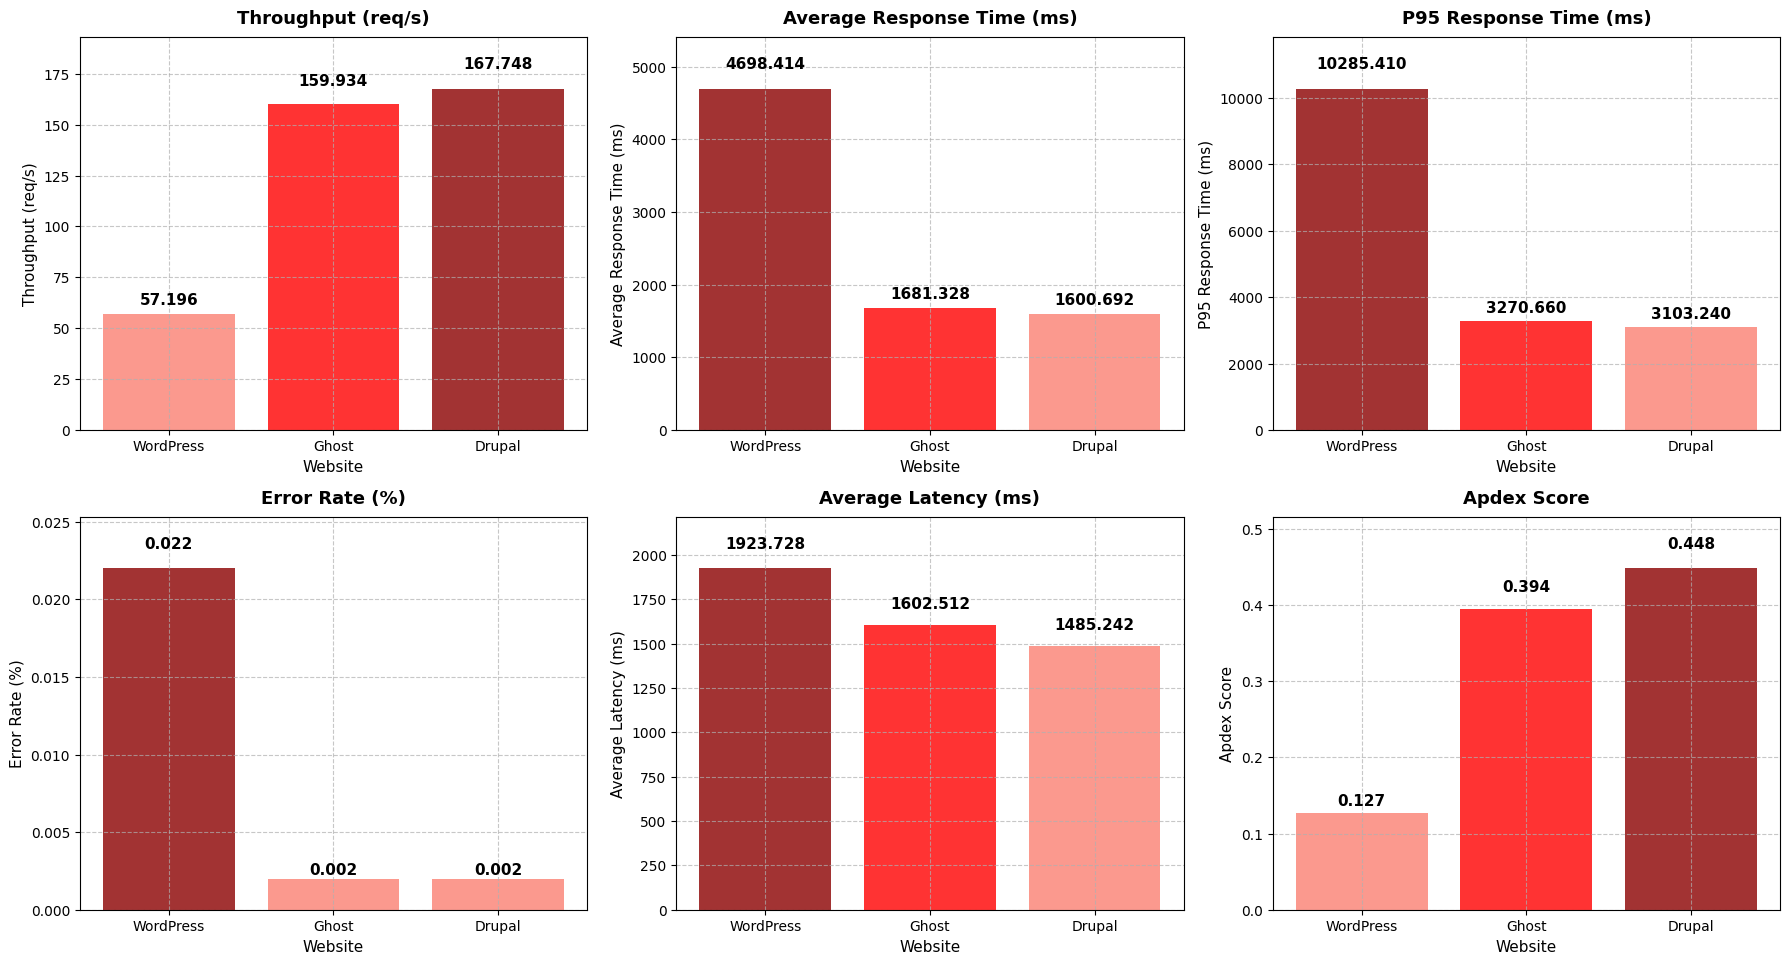

In [5]:
fig, axs = plt.subplots(3, 3, figsize=(18, 15))

metrics = [
    ('throughput (req/s)', 'Throughput (req/s)'         ),
    ('avg_response (ms)',  'Average Response Time (ms)' ),
    ('p95_response (ms)',  'P95 Response Time (ms)'     ),
    ('error_rate (%)',     'Error Rate (%)'             ),
    ('avg_latency (ms)',   'Average Latency (ms)'       ),
    ('apdex',              'Apdex Score'                ),
]

for i, (col, title) in enumerate(metrics):
    row, col_idx = divmod(i, 3)

    values = result[col]
    uniques = sorted(values.unique())
    
    def color_map(v):
        if len(uniques) == 1:
            return 'red'
        elif len(uniques) == 2:
            return 'salmon' if v == uniques[0] else 'darkred'
        else:
            if v == uniques[0]:
                return 'salmon'
            elif v == uniques[-1]:
                return 'darkred'
            else:
                return 'red'
    
    colors = [color_map(v) for v in values]

    bars = axs[row, col_idx].bar(result['website'], result[col], color=colors, alpha=0.8)
    
    axs[row, col_idx].set_title(title, fontsize=13, fontweight='bold', pad=10)
    axs[row, col_idx].set_xlabel("Website", fontsize=11)
    axs[row, col_idx].set_ylabel(title, fontsize=11)
    axs[row, col_idx].grid(True, linestyle='--', alpha=0.7)

    max_val = result[col].max()
    axs[row, col_idx].set_ylim(0, max_val * 1.15)
    
    for bar in bars:
        height = bar.get_height()
        axs[row, col_idx].text(bar.get_x() + bar.get_width()/2, height * 1.05, 
                               f'{height:.3f}', ha='center', va='bottom', 
                               fontsize=11, fontweight='bold')

for j in range(6, 9):
    axs.flat[j].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("Assets Testing/Incremental/Base Cache/Comparison Report - Incremental Base Cache.png")
plt.show()

In [6]:
wordpress_result    = "Wordpress Summary/IncrementalTesting/BaseCache/Wordpress Result - Incremental Base Summary.csv"
ghost_result = "Ghost Summary/IncrementalTesting/BaseCache/Ghost Result - Incremental Base Summary.csv"
drupal_result = "Drupal Summary/IncrementalTesting/BaseCache/Drupal Result - Incremental Base Summary.csv"

wordpress_result_monitor = pd.read_csv(wordpress_result)
ghost_result_monitor = pd.read_csv(ghost_result)
drupal_result_monitor = pd.read_csv(drupal_result)

In [7]:
wordpress_result_monitoring = wordpress_result_monitor.iloc[-1:].copy()
ghost_result_monitoring = ghost_result_monitor.iloc[-1:].copy()
drupal_result_monitoring = drupal_result_monitor.iloc[-1:].copy()

wordpress_result_monitoring['Website'] = 'WordPress'
ghost_result_monitoring['Website'] = 'Ghost'
drupal_result_monitoring['Website'] = 'Drupal'

result_comparison = pd.concat([wordpress_result_monitoring, ghost_result_monitoring, drupal_result_monitoring], ignore_index=True)

In [8]:
cols_result_monitoring = ['Website', 'Avg CPU (m)', 'Max CPU (m)', 'Avg Memory (Mi)', 'Max Memory (Mi)', 'Avg Ingress CPU (m)', 'Max Ingress CPU (m)', 'Avg Ingress Memory (Mi)', 'Max Ingress Memory (Mi)']

result_monitoring = result_comparison[cols_result_monitoring].round(3)
result_monitoring.to_csv("Assets Testing/Incremental/Base Cache/Comparison Result - Incremental Base Cache.csv", index=False)

styled = (result_monitoring.style
          .hide(axis="index")
          .format(precision=3)
          .set_table_styles([
              {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]}
          ]))

display(styled)

Website,Avg CPU (m),Max CPU (m),Avg Memory (Mi),Max Memory (Mi),Avg Ingress CPU (m),Max Ingress CPU (m),Avg Ingress Memory (Mi),Max Ingress Memory (Mi)
WordPress,2.160,4.800,283.196,460.600,34.072,58.600,50.044,54.000
Ghost,3.978,15.800,248.340,384.000,49.552,70.800,51.586,55.000
Drupal,16.186,39.400,336.904,465.400,54.078,74.200,83.948,87.000


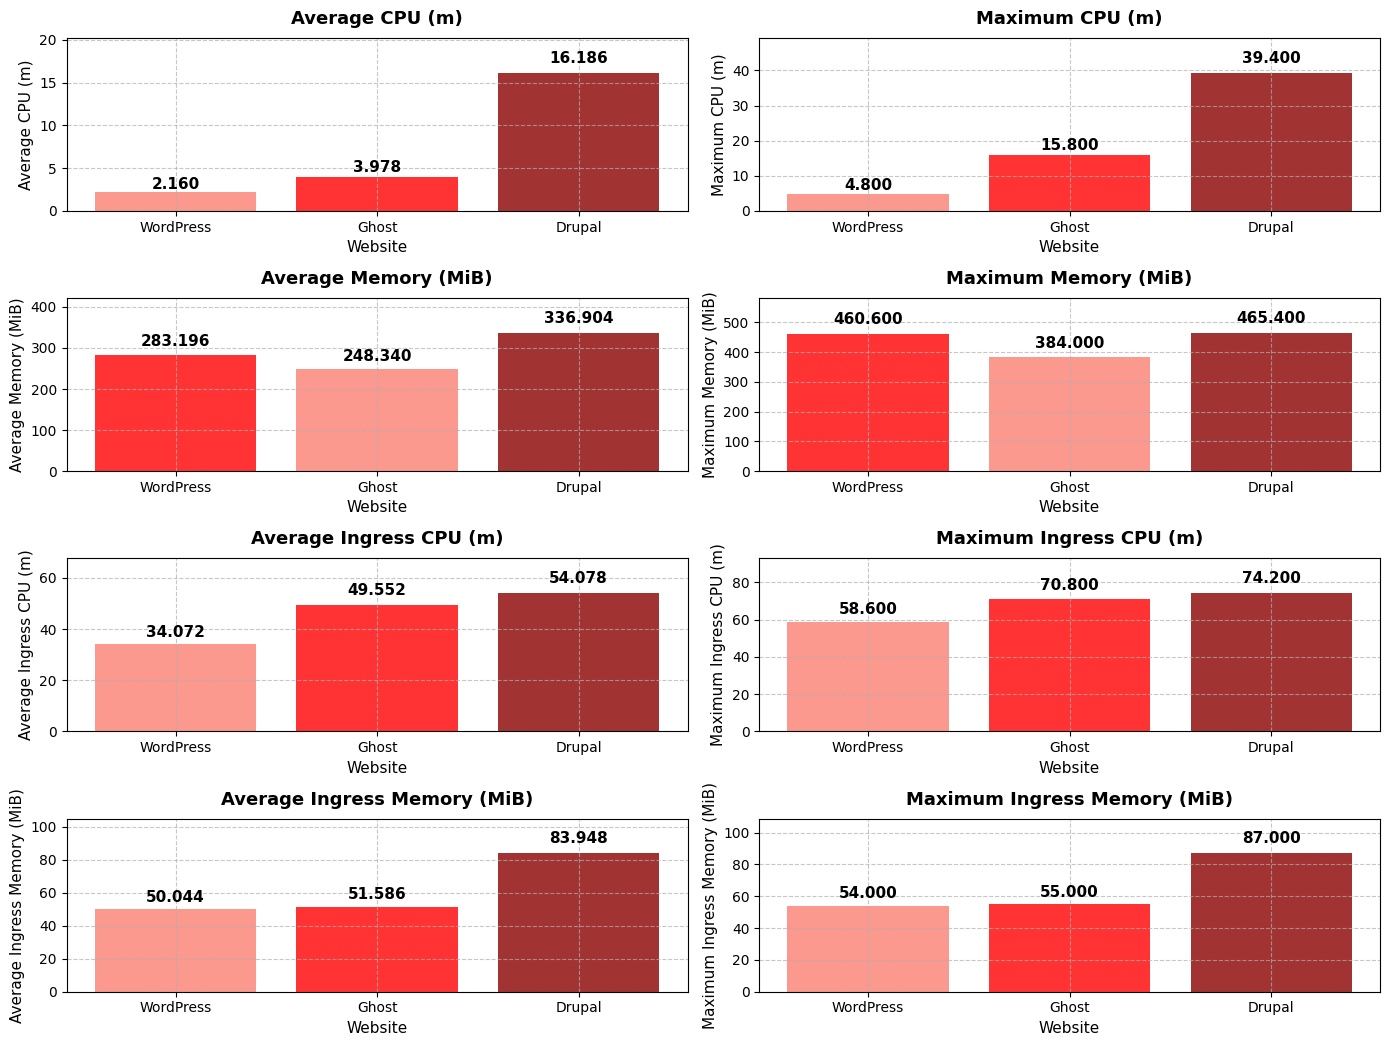

In [9]:
fig, axs = plt.subplots(4, 2, figsize=(14, 11))

metrics = [
    ('Avg CPU (m)',             'Average CPU (m)'              ),
    ('Max CPU (m)',             'Maximum CPU (m)'              ),
    ('Avg Memory (Mi)',         'Average Memory (MiB)'         ),
    ('Max Memory (Mi)',         'Maximum Memory (MiB)'         ),
    ('Avg Ingress CPU (m)',     'Average Ingress CPU (m)'      ),
    ('Max Ingress CPU (m)',     'Maximum Ingress CPU (m)'      ),
    ('Avg Ingress Memory (Mi)', 'Average Ingress Memory (MiB)' ),
    ('Max Ingress Memory (Mi)', 'Maximum Ingress Memory (MiB)' ),
]

for i, (col, title) in enumerate(metrics):
    row, col_idx = divmod(i, 2)

    values = result_monitoring[col]
    uniques = sorted(values.unique())
    
    def color_map(v):
        if len(uniques) == 1:
            return 'red'
        elif len(uniques) == 2:
            return 'salmon' if v == uniques[0] else 'darkred'
        else:
            if v == uniques[0]:
                return 'salmon'
            elif v == uniques[-1]:
                return 'darkred'
            else:
                return 'red'
    
    colors = [color_map(v) for v in values]
    
    bars = axs[row, col_idx].bar(result_monitoring['Website'], result_monitoring[col], color=colors, alpha=0.8)
    
    axs[row, col_idx].set_title(title, fontsize=13, fontweight='bold', pad=10)
    axs[row, col_idx].set_xlabel("Website", fontsize=11)
    axs[row, col_idx].set_ylabel(title, fontsize=11)
    axs[row, col_idx].grid(True, linestyle='--', alpha=0.7)

    max_val = result_monitoring[col].max()
    axs[row, col_idx].set_ylim(0, max_val * 1.25)
    
    for bar in bars:
        height = bar.get_height()
        axs[row, col_idx].text(bar.get_x() + bar.get_width()/2, height * 1.05, 
                               f'{height:.3f}', ha='center', va='bottom', 
                               fontsize=11, fontweight='bold')


plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("Assets Testing/Incremental/Base Cache/Comparison Result - Incremental Base Cache.png")
plt.show()

In [10]:
wordpress_kernel    = "Wordpress Summary/IncrementalTesting/BaseCache/Wordpress Kernel - Incremental Base Summary.csv"
ghost_kernel = "Ghost Summary/IncrementalTesting/BaseCache/Ghost Kernel - Incremental Base Summary.csv"
drupal_kernel = "Drupal Summary/IncrementalTesting/BaseCache/Drupal Kernel - Incremental Base Summary.csv"

wordpress_kernel_monitor = pd.read_csv(wordpress_kernel)
ghost_kernel_monitor = pd.read_csv(ghost_kernel)
drupal_kernel_monitor = pd.read_csv(drupal_kernel)

In [11]:
wordpress_kernel_monitoring = wordpress_kernel_monitor.iloc[-1:].copy()
ghost_kernel_monitoring = ghost_kernel_monitor.iloc[-1:].copy()
drupal_kernel_monitoring = drupal_kernel_monitor.iloc[-1:].copy()

wordpress_kernel_monitoring['Website'] = 'WordPress'
ghost_kernel_monitoring['Website'] = 'Ghost'
drupal_kernel_monitoring['Website'] = 'Drupal'

kernel_comparison = pd.concat([wordpress_kernel_monitoring, ghost_kernel_monitoring, drupal_kernel_monitoring], ignore_index=True)

In [12]:
cols_kernel_monitoring = ['Website', 'Avg CPU (%)', 'Max CPU (%)', 'Avg Memory (MB)', 'Max Memory (MB)', 'Avg I/O (S)', 'Max I/O (S)', 'Context Switches']

kernel_monitoring = kernel_comparison[cols_kernel_monitoring].round(3)
kernel_monitoring.to_csv("Assets Testing/Incremental/Base Cache/Comparison Kernel - Incremental Base Cache.csv", index=False)

styled = (kernel_monitoring.style
          .hide(axis="index")
          .format(precision=3)
          .set_table_styles([
              {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]}
          ]))

display(styled)

Website,Avg CPU (%),Max CPU (%),Avg Memory (MB),Max Memory (MB),Avg I/O (S),Max I/O (S),Context Switches
WordPress,14.464,29.400,4315.810,4346.600,314.050,1959.200,16277.658
Ghost,16.212,33.800,4326.268,4352.400,350.694,2466.400,18157.316
Drupal,18.288,38.200,4274.340,4305.400,762.914,5356.800,18897.426


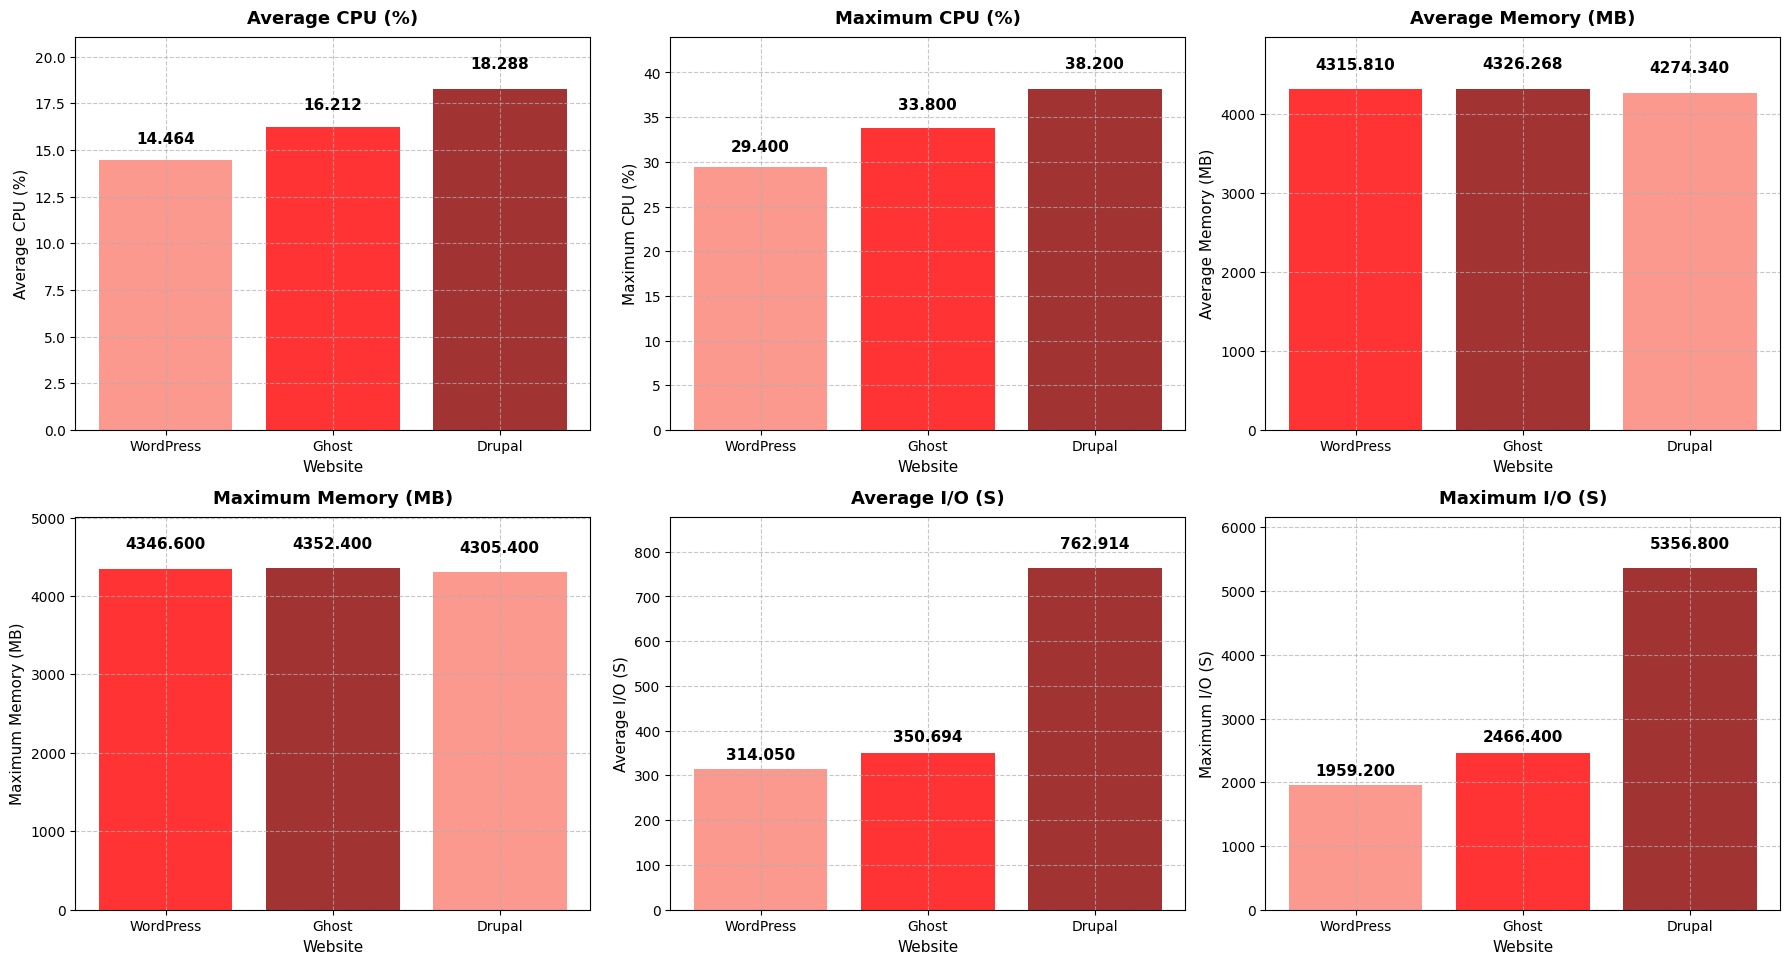

In [13]:
fig, axs = plt.subplots(3, 3, figsize=(18, 15))

metrics = [
    ('Avg CPU (%)',     'Average CPU (%)'     ),
    ('Max CPU (%)',     'Maximum CPU (%)'     ),
    ('Avg Memory (MB)', 'Average Memory (MB)' ),
    ('Max Memory (MB)', 'Maximum Memory (MB)' ),
    ('Avg I/O (S)',     'Average I/O (S)'     ), 
    ('Max I/O (S)',     'Maximum I/O (S)'     ),
]

for i, (col, title) in enumerate(metrics):
    row, col_idx = divmod(i, 3)

    values = kernel_monitoring[col]
    uniques = sorted(values.unique())
    
    def color_map(v):
        if len(uniques) == 1:
            return 'red'
        elif len(uniques) == 2:
            return 'salmon' if v == uniques[0] else 'darkred'
        else:
            if v == uniques[0]:
                return 'salmon'
            elif v == uniques[-1]:
                return 'darkred'
            else:
                return 'red'
    
    colors = [color_map(v) for v in values]
    
    bars = axs[row, col_idx].bar(kernel_monitoring['Website'], kernel_monitoring[col], color=colors, alpha=0.8)
    
    axs[row, col_idx].set_title(title, fontsize=13, fontweight='bold', pad=10)
    axs[row, col_idx].set_xlabel("Website", fontsize=11)
    axs[row, col_idx].set_ylabel(title, fontsize=11)
    axs[row, col_idx].grid(True, linestyle='--', alpha=0.7)

    max_val = kernel_monitoring[col].max()
    axs[row, col_idx].set_ylim(0, max_val * 1.15)
    
    for bar in bars:
        height = bar.get_height()
        axs[row, col_idx].text(bar.get_x() + bar.get_width()/2, height * 1.05, 
                               f'{height:.3f}', ha='center', va='bottom', 
                               fontsize=11, fontweight='bold')

for j in range(6, 9):
    axs.flat[j].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("Assets Testing/Incremental/Base Cache/Comparison Kernel - Incremental Base Cache.png")
plt.show()